<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Introduction to Machine Learning
</font>
<hr/>
<font color="#800080" size=5>
Phase 2
<br>
</font>
<font size=5>
Instructor: Dr. S. Amini
<br>
</font>
<font size=4>
Fall 2025
<br>
<hr>
</font>
<font face="Times New Roman" size=4 align=center>
</font>
</div></font>

## 1. Theoretical Questions

## Question 1

## part 1

We have a binary image so each pixel is either one or zero so all the possabilities are $2^D$ and since all the probabilities should some up to one so we need $2^D - 1$ paramaters.

## part 2

we know that $W \in R^{H \times D}, V \in R^{D \times H}, c \in R^{H}, b \in R^{D}$ so all we need is $HD + DH + H + D = 2HD + D + H$.

## PART 3

In the first one the parameters are exponential and in the second one they are linear even in the worst scenario they are $D^2$.
To sum it up $O(2^D)$ is much bigger than $O(D)$ or $O(D^2)$

## Question 2

## part 1

Formulation of NADE is: 

$h_d = \sigma\!\left(W_{:,<d}\, x_{<d} + c\right) = \sigma(a_d)$

$\hat{x}_d = p(x_d = 1 \mid x_{<d}) = \sigma\!\left(V_d^{\top} h_d + b_d\right)$

Now we jump on utilizing weight sharing:

$a_d = W_{.,<d}x_{<d} + c = \sum_{j < d} x_jW_{:,j} + c$

$a_{d + 1} = W_{.,<d + 1}x_{<d + 1} + c = \sum_{j < d + 1} x_jW_{:,j} + c = \sum_{j < d} x_jW_{:,j} + x_dW_{:,d} + c = a_d + x_dW_{:,d}$\

so we can calculate $a_{d + 1}$ with $a_{d}$ and $x_d$

$a_{d + 1} = a_d + x_dW_{:,d}$

## part 2

We calculate the time complexity for each parameter.

for $a_i \rightarrow O(H)$

for $h_i \rightarrow O(H)$

for $x_i \rightarrow O(H)$

which cause we have D pixles the final answer is $O(HD)$

Now if we do not use recursive: 

for pixle d $O(Hd)$ so in total it will be:

$\sum_{d = 1} ^ D O(Hd) = O(H\sum_{d = 1} ^ D d) = O(H \frac{D(D+1)}{2}) = O(HD^2)$


## Question 3

## part 1

$p(x) = \prod_{d = 1} ^ D p(x_d|x_{<d})$

$log p(x) = \sum_{d = 1} ^ D log p(x_d|x_{<d})$

$p(x_d = 1|x_{<d}) = \hat x_d$

$p(x_d|x_{<d}) = \hat x_d ^ {x_d} (1 - \hat x_d) ^ {1 - x_d}$

$log p(x_d|x_{<d}) = x_d log \hat x_d + (1 - x_d) log (1 - \hat x_d)$

$log p(x) = \sum_{d = 1} ^ D x_d log \hat x_d + (1 - x_d) log (1 - \hat x_d)$

$- log p(x) = - \sum_{d = 1} ^ D x_d log \hat x_d + (1 - x_d) log (1 - \hat x_d)$

Thus we have proven minimizing the negative log-likelihood of the joint distribution p(x) is equivalent to minimizing the sum of Binary Cross Entropy (BCE) losses for each
individual pixel d.

## part 2

In NADE we assumed that each pixel is binary but MNIST dataset pixels are continuous values [0, 1]. If we use not binarized pixles we get:

$p(x_d | x_{<d}) = Bernoulli(\hat x_d)$

The output of bernoulli is 0 or 1 and if x a number between these two this observation will be wrong.

## Question 4

## part 1

If we have all the parameters of a trained NADE model we start from $a_1$ by going through the fallowing proccess we get aoll the values for the new image.

for d = 1, 2, ..., D:

a_1 = constant

$h_d = \sigma(a_d)$

$\hat x_d = p(x_d = 1 | x_{<d}) = \sigma(V_d^Th_d + b_d)$

$x_d \sim Ber(\hat x_d)$

$a_{d + 1} = a_d + x_dW_{:,d}$

If we repeat proccess we get all the values for the new image.

## part 2

To create $x_d$ all the $x_{<d}$ should be known so pixles should be made in one by one and in order so it is sequential.

To score we know all the values of $x_d$ so we just need to evaluate the probabilities and by using $a_{d + 1} = a_d + x_dW_{:,d}$ we compute likelihood in one forward pass.

## 2. Practical Implementation & Experiments

## Dataset Prepration

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()

mnist_train = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

mnist_test = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

all_data = torch.cat([mnist_train.data, mnist_test.data], dim=0).float() / 255.0
all_targets = torch.cat([mnist_train.targets, mnist_test.targets], dim=0)


all_data = (all_data > 0.5).float()

all_data = all_data.view(-1, 784)


id_mask = all_targets < 5
X_id = all_data[id_mask]
y_id = all_targets[id_mask]

ood_mask = all_targets >= 5
X_ood = all_data[ood_mask]
y_ood = all_targets[ood_mask]

X_train, X_val, y_train, y_val = train_test_split(
    X_id,
    y_id,
    test_size=0.2,
    random_state=42,
    stratify=y_id
)

batch_size = 128

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=batch_size,
    shuffle=False
)

ood_loader = DataLoader(
    TensorDataset(X_ood, y_ood),
    batch_size=batch_size,
    shuffle=False
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("OOD set:", X_ood.shape)

Train set: torch.Size([28588, 784])
Validation set: torch.Size([7147, 784])
OOD set: torch.Size([34265, 784])


## Task 1: Implement NADE

In [2]:
import numpy as np

class NADE:
    def __init__(self, n_visible=784, n_hidden=500, seed=42):
        np.random.seed(seed)
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        
        # Initialize weights
        self.W = 0.01 * np.random.randn(n_visible, n_hidden)
        self.V = 0.01 * np.random.randn(n_hidden, n_visible)
        self.b = np.zeros(n_visible)
        self.c = np.zeros(n_hidden)
        
        # Adam optimizer parameters
        self.mW = np.zeros_like(self.W)
        self.vW = np.zeros_like(self.W)
        self.mV = np.zeros_like(self.V)
        self.vV = np.zeros_like(self.V)
        self.mb = np.zeros_like(self.b)
        self.vb = np.zeros_like(self.b)
        self.mc = np.zeros_like(self.c)
        self.vc = np.zeros_like(self.c)
        self.beta1 = 0.9
        self.beta2 = 0.999
        self.eps = 1e-8
        self.t = 0
        
    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))
    
    def forward(self, x):
        batch_size = x.shape[0]
        h_act = np.zeros((batch_size, self.n_hidden))
        log_prob = np.zeros(batch_size)
        
        for i in range(self.n_visible):
            h = self.sigmoid(self.c + h_act)
            p_i = self.sigmoid(self.b[i] + np.dot(h, self.V[:, i]))
            
            log_prob += x[:, i] * np.log(p_i + 1e-10) + (1 - x[:, i]) * np.log(1 - p_i + 1e-10)
            h_act += x[:, i].reshape(-1, 1) * self.W[i, :]
        
        return log_prob

    def sample(self, n_samples):
        samples = np.zeros((n_samples, self.n_visible))
        h_act = np.zeros((n_samples, self.n_hidden))
        
        for i in range(self.n_visible):
            h = self.sigmoid(self.c + h_act)
            p_i = self.sigmoid(self.b[i] + np.dot(h, self.V[:, i]))
            
            samples[:, i] = np.random.binomial(1, p_i)
            h_act += samples[:, i].reshape(-1, 1) * self.W[i, :]
        
        return samples
    
    def train_step(self, x, lr=0.001):
        batch_size = x.shape[0]
        h_act = np.zeros((batch_size, self.n_hidden))
        h_list = []
        p_list = []
        
        for i in range(self.n_visible):
            h = self.sigmoid(self.c + h_act)
            p_i = self.sigmoid(self.b[i] + np.dot(h, self.V[:, i]))
            
            h_list.append(h)
            p_list.append(p_i)
            h_act += x[:, i].reshape(-1, 1) * self.W[i, :]
        
        dW = np.zeros_like(self.W)
        dV = np.zeros_like(self.V)
        db = np.zeros_like(self.b)
        dc = np.zeros_like(self.c)
        
        dh_next = np.zeros((batch_size, self.n_hidden))
        h_act = np.zeros((batch_size, self.n_hidden))
        
        for i in range(self.n_visible):
            h = h_list[i]
            p_i = p_list[i]
            dp = x[:, i] - p_i 
            
            dV[:, i] += np.dot(h.T, dp) / batch_size
            db[i] += np.sum(dp) / batch_size
            
            dh = np.outer(dp, self.V[:, i]) + dh_next
            dh_raw = dh * h * (1 - h)
            
            dW[i, :] += np.sum(dh_raw * x[:, i].reshape(-1, 1), axis=0) / batch_size
            dc += np.sum(dh_raw, axis=0) / batch_size
            
            dh_next = dh_raw * 0 
            
            h_act += x[:, i].reshape(-1, 1) * self.W[i, :]
        
        self.t += 1
        for param, grad, m, v in zip(
            [self.W, self.V, self.b, self.c],
            [dW, dV, db, dc],
            [self.mW, self.mV, self.mb, self.mc],
            [self.vW, self.vV, self.vb, self.vc]
        ):
            m[:] = self.beta1 * m + (1 - self.beta1) * grad
            v[:] = self.beta2 * v + (1 - self.beta2) * (grad ** 2)
            m_hat = m / (1 - self.beta1 ** self.t)
            v_hat = v / (1 - self.beta2 ** self.t)
            param += lr * m_hat / (np.sqrt(v_hat) + self.eps)

        return -np.mean(self.forward(x))
    

## Task 2: Training

Epoch 1/15 | Train Loss: 187.0889 | Val Loss: 141.0054
Epoch 2/15 | Train Loss: 127.9796 | Val Loss: 119.0909
Epoch 3/15 | Train Loss: 114.2486 | Val Loss: 110.5632
Epoch 4/15 | Train Loss: 107.6422 | Val Loss: 105.7046
Epoch 5/15 | Train Loss: 103.4847 | Val Loss: 102.3638
Epoch 6/15 | Train Loss: 100.6045 | Val Loss: 100.1202
Epoch 7/15 | Train Loss: 98.4610 | Val Loss: 98.4358
Epoch 8/15 | Train Loss: 96.8331 | Val Loss: 97.1615
Epoch 9/15 | Train Loss: 95.5054 | Val Loss: 96.0807
Epoch 10/15 | Train Loss: 94.4059 | Val Loss: 95.1724
Epoch 11/15 | Train Loss: 93.4649 | Val Loss: 94.3740
Epoch 12/15 | Train Loss: 92.6406 | Val Loss: 93.7779
Epoch 13/15 | Train Loss: 91.9150 | Val Loss: 93.1514
Epoch 14/15 | Train Loss: 91.2537 | Val Loss: 92.5774
Epoch 15/15 | Train Loss: 90.6623 | Val Loss: 92.0958


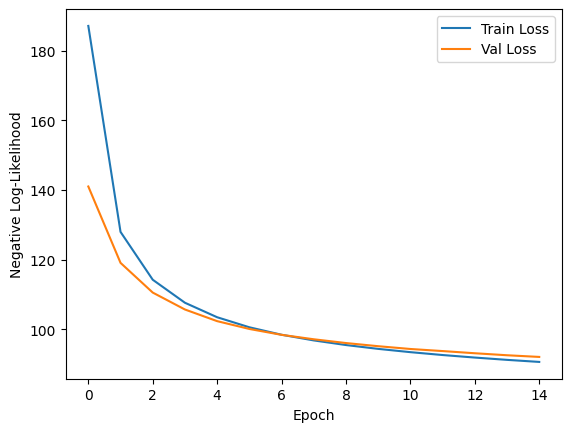

In [3]:
import numpy as np
import matplotlib.pyplot as plt

X_train_np = X_train.numpy()
X_val_np = X_val.numpy()

nade = NADE(n_visible=784, n_hidden=500)

epochs = 15
batch_size = 128
lr = 0.001

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    perm = np.random.permutation(X_train_np.shape[0])
    X_train_np = X_train_np[perm]
    
    epoch_loss = 0
    for i in range(0, X_train_np.shape[0], batch_size):
        x_batch = X_train_np[i:i+batch_size]
        loss = nade.train_step(x_batch, lr)
        epoch_loss += loss * x_batch.shape[0]
    
    epoch_loss /= X_train_np.shape[0]
    train_loss_history.append(epoch_loss)
    
    val_logp = nade.forward(X_val_np)
    val_loss = -np.mean(val_logp)
    val_loss_history.append(val_loss)
    
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.legend()
plt.show()


## Task 3: OOD Detection

Average log-likelihood for ID test set: -92.09578872226294
Average log-likelihood for OOD test set: -133.81383057758774


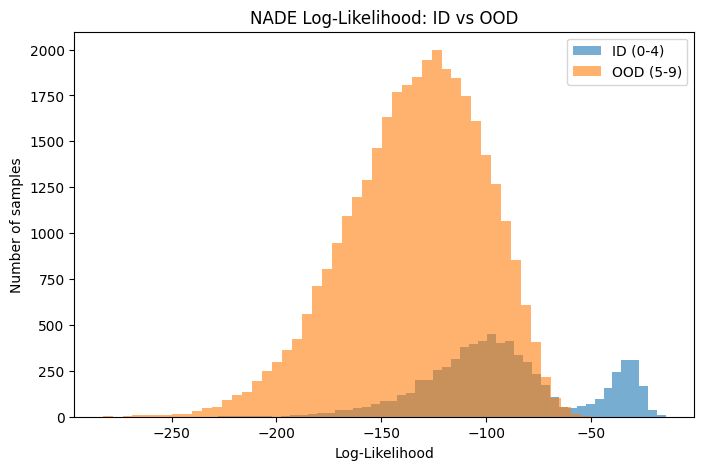

AUROC for OOD detection: 0.7983426772839477


In [4]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

X_val_np = X_val.numpy()      
X_ood_np = X_ood.numpy()      

logp_id = nade.forward(X_val_np)  
logp_ood = nade.forward(X_ood_np) 

print("Average log-likelihood for ID test set:", np.mean(logp_id))
print("Average log-likelihood for OOD test set:", np.mean(logp_ood))

plt.figure(figsize=(8,5))
plt.hist(logp_id, bins=50, alpha=0.6, label='ID (0-4)')
plt.hist(logp_ood, bins=50, alpha=0.6, label='OOD (5-9)')
plt.xlabel("Log-Likelihood")
plt.ylabel("Number of samples")
plt.title("NADE Log-Likelihood: ID vs OOD")
plt.legend()
plt.show()

y_true = np.concatenate([np.zeros_like(logp_id), np.ones_like(logp_ood)]) 
scores = np.concatenate([logp_id, logp_ood])

anomaly_scores = -scores

auroc = roc_auc_score(y_true, anomaly_scores)
print("AUROC for OOD detection:", auroc)



The separation is not perfect as it is seen in the plot and there are some overlaps. The reason for this accurance is that in general numbers [0, 9] are simillar and it is not like we can say that [0, 4] are very different from [5, 9]. But we still get a AUROC of 0.778 which means our model is working better than a random (0.5) model. Which means our model is able to detect OOD from ID but to some extent and it is possible to make some mistakes.

## Task 4: Generation

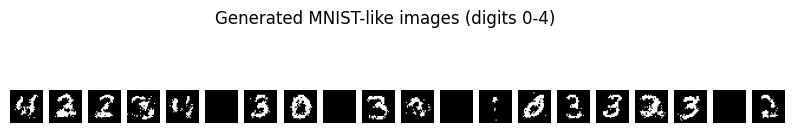

In [6]:
n_samples = 20
samples = nade.sample(n_samples)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))

for i in range(n_samples):
    plt.subplot(1, n_samples, i+1)
    plt.imshow(samples[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.suptitle("Generated MNIST-like images (digits 0-4)")
plt.show()


We can see that the images that are being made are simillar to numbers [0, 4] and there isnot a number that looks like [5, 9] and the reason for this is that we trained our model on numbers [0, 4]. For the quality of the pictures we can say that they are similar but the are not exactly like the numbers because they are generated based on probability and sometimes even with the best parametrs there is a change that we get the wrong pixles.

## 